# １章３節７項 アンビギュイティ

## 概要
アジマスアンビギュイティの距離推定とその可視化です。

## 使用データ

| 項目 | 情報 |
| ---- | ---- | 
| 衛星 | ALOS PALSAR |
| 観測シーンID　| `ALPSRP273720830`　|
| データリンク | [ASF](https://search.asf.alaska.edu/#/?dataset=ALOS&zoom=7.178&center=140.466,40.105&resultsLoaded=true&granule=ALPSRP273720830-KMZ&maxResults=250&searchType=List%20Search&searchList=ALPSRP273720830) Level 1.1 Image |
| 画像クレジット| © JAXA |

書籍に記載されている例
- [Synspective Data Gallary: シンガポール港](https://synspective.com/jp/gallery/port-of-singapore-singapore/) 

## Azimuth Ambiguity

In [ ]:
import os
import numpy as np
import warnings
import tifffile
import cv2

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt


PATH_OUTPUT = os.path.join('output', f'1_3_7')
os.makedirs(PATH_OUTPUT, exist_ok=True)

from utils.ceos_io import ALOSPALSARData

In [3]:
PATH_ROOT_ALOS_M = '../data/ambiguity/ALPSRP273720830-H1.1__A/'

alos_m = ALOSPALSARData(PATH_ROOT_ALOS_M)
slc_m = alos_m.read_slc(cache=False)

Reading Signal...: 100%|███████████████▉| 18431/18432 [00:13<00:00, 1356.17it/s]


In [ ]:
prf = alos_m.read_pulse_repetation_frequency()
print(f'PRF: {prf}') # 2155.2 [Hz]

PRF: 2155.1724137931


In [5]:
(orb_m, xyz_velocity, obs_m) = alos_m.read_orbit(velocity=True)
orb_m.shape, xyz_velocity.shape, obs_m.shape

((18432, 3), (18432, 3), (18432,))

In [6]:
pos_m = alos_m.read_location()
(A, B, CS, CL) = alos_m.read_geo_matrix()
xyz_m_loc, (idx_sample, idx_line) = alos_m.read_xyz_raster(A, B, CS, CL)

from utils.interferogram import get_slant_range

slant_m = get_slant_range(orb_m, xyz_m_loc, idx_line)
slant_m.shape

(18432, 9344)

In [7]:
from utils.interferogram import get_angle_vectors, get_incident_angle

incident_angle = get_incident_angle(xyz_m_loc, orb=orb_m, idx_line=idx_line)

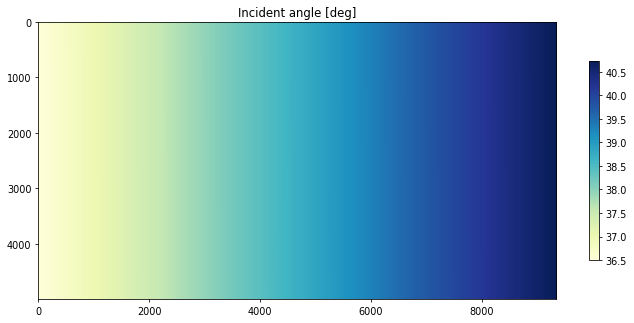

In [8]:
plt.figure(figsize=(10, 6), dpi=70, facecolor='w', edgecolor='k')
plt.imshow(np.degrees(incident_angle[7500:12500]), cmap='YlGnBu',)
plt.colorbar(shrink=0.5)
plt.title('Incident angle [deg]')
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'alos_incident_angle.png'))
plt.show();plt.clf();plt.close()

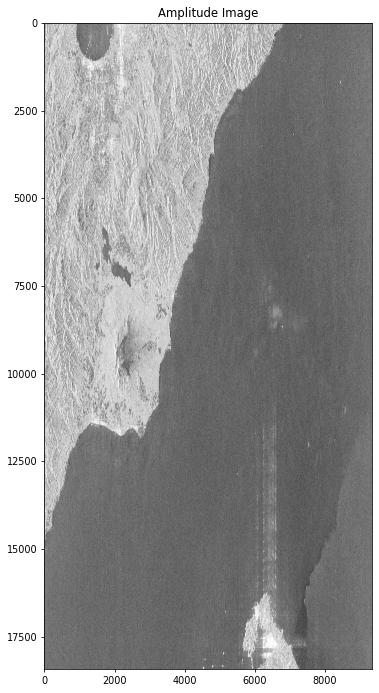

In [9]:
amp_m = np.abs(slc_m[0])

plt.figure(figsize=(8, 10), dpi=70, facecolor='w', edgecolor='k')
plt.imshow(amp_m, cmap='gray')
plt.title('Amplitude Image')
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'alos_amplitude.png'))
plt.show();plt.clf();plt.close()

## Azimuth Ambiguity

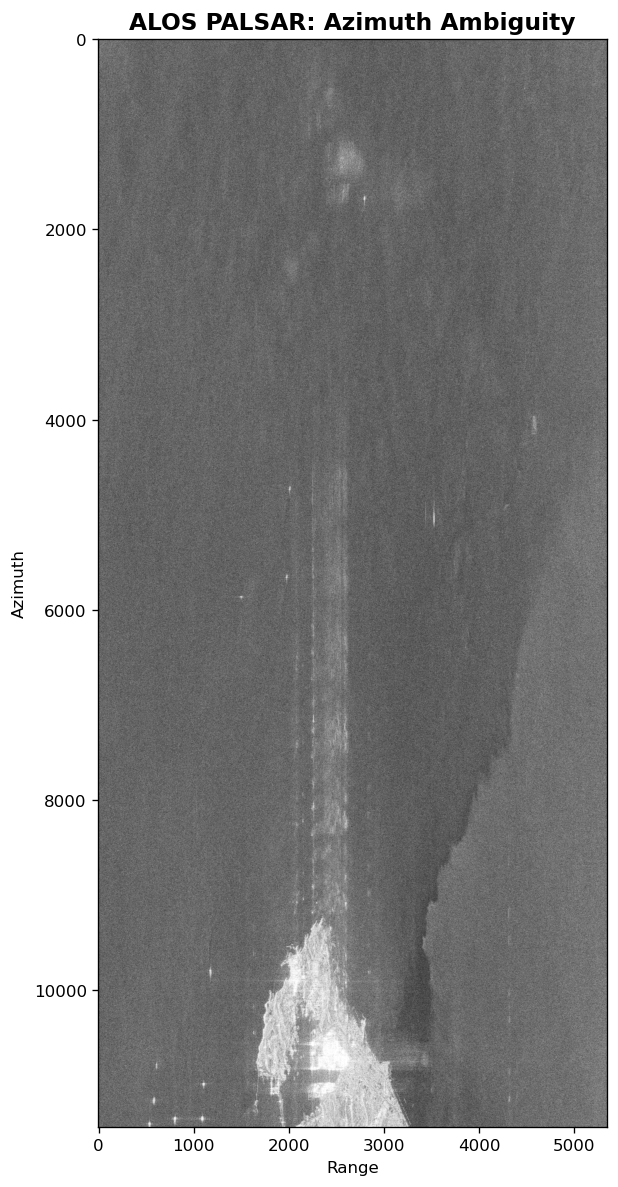

In [11]:
patch_r = 4000
patch_a = 7000

amp_patch = amp_m[patch_a:, patch_r:]

plt.figure(figsize=(8, 10), dpi=120, facecolor='w', edgecolor='k')
plt.title('ALOS PALSAR: Azimuth Ambiguity', fontsize=14, fontweight='bold')
plt.imshow(amp_patch, cmap='gray')
plt.xlabel('Range')
plt.ylabel('Azimuth')
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'alos_amp_azimuth_ambiguity.png'))
plt.show();plt.clf();plt.close()

Satellite Velocity: 7.59 [km/s]
Distance Ambiguity: 29.47 [km]


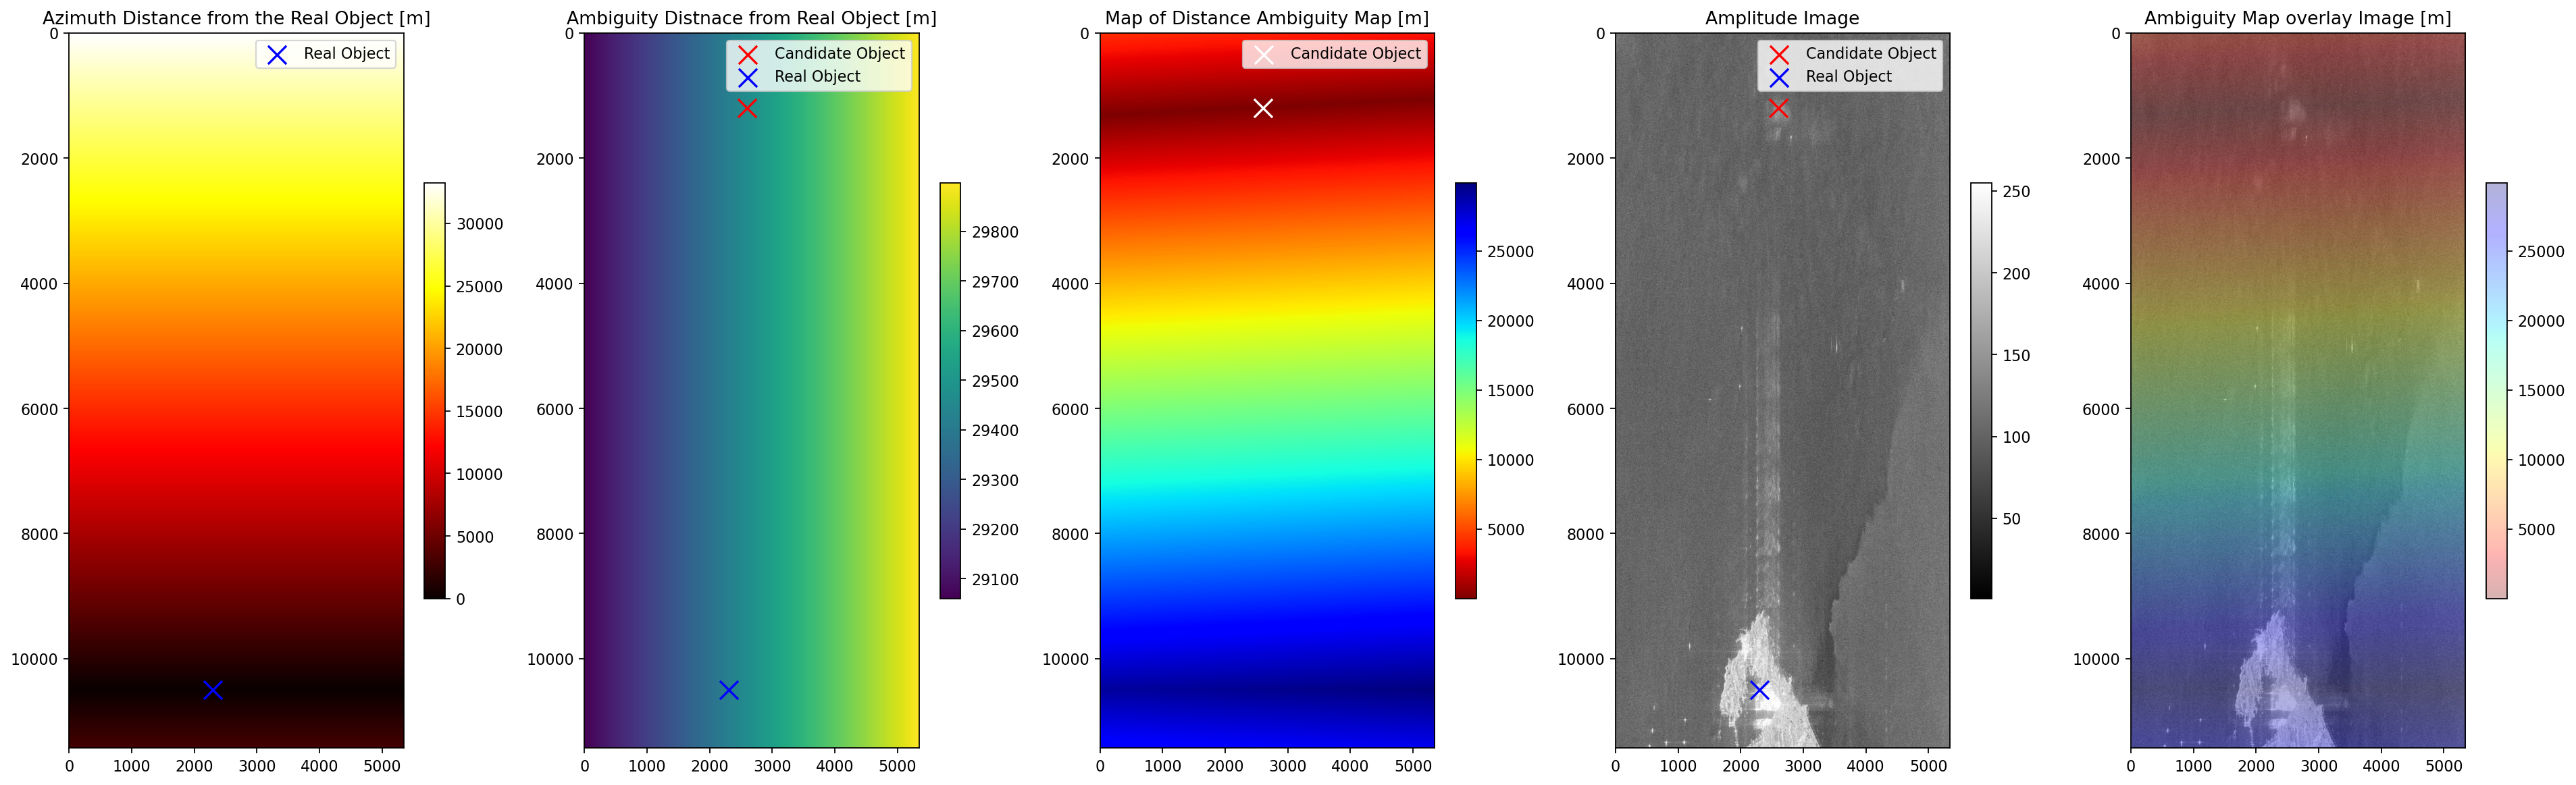

In [ ]:
# simple resolution
spacing_azimuth = 3.167

range_patch, azimuth_patch = amp_patch.shape
pixel_real_obj = (10500, 2300)
ambiguity_candidate = (1200, 2600)

wave_length = alos_m.wave_length
velocity = np.linalg.norm(xyz_velocity[int(pixel_real_obj[0])])
print(f'Satellite Velocity: {velocity * 1e-3:.2f} [km/s]')
slant_range = slant_m[patch_a:, patch_r:]


distance_ambiguity = prf * wave_length * slant_range / (2 * velocity)
print(f'Distance Ambiguity: {distance_ambiguity[ambiguity_candidate[0], ambiguity_candidate[1]] * 1e-3:.2f} [km]')


# distance from the pixel
distance_from_pixel_azimuth = np.abs(np.arange(range_patch) - pixel_real_obj[0])
distance_from_point = np.stack([distance_from_pixel_azimuth] * azimuth_patch, axis=1)
distance_from_point = distance_from_point.astype(np.float32) * spacing_azimuth

distance_ammbiguity_map = np.abs(distance_from_point - distance_ambiguity)

plt.figure(figsize=(24, 8), dpi=160, facecolor='w', edgecolor='k')
plt.subplot(151)
plt.imshow(distance_from_point, cmap='hot')
plt.colorbar(shrink=0.5)
plt.scatter(*pixel_real_obj[::-1], 
            s=150, c='b', marker='x', label='Real Object')
plt.title('Azimuth Distance from the Real Object [m]')
plt.legend()

plt.subplot(152)
plt.title('Ambiguity Distance from Real Object [m]')
plt.imshow(distance_ambiguity, cmap='viridis')
plt.colorbar(shrink=0.5)
plt.scatter(*ambiguity_candidate[::-1], s=150, c='r', marker='x', label='Candidate Object')
plt.scatter(*pixel_real_obj[::-1], 
            s=150, c='b', marker='x', label='Real Object')
plt.legend()

plt.subplot(153)
plt.imshow(distance_ammbiguity_map, cmap='jet_r')
plt.colorbar(shrink=0.5)
plt.title('Map of Distance Ambiguity Map [m]')
plt.scatter(*ambiguity_candidate[::-1], s=150, c='w', marker='x', label='Candidate Object')
plt.legend()

plt.subplot(154)
plt.imshow(amp_patch, cmap='gray')
plt.colorbar(shrink=0.5)
plt.title('Amplitude Image')
plt.scatter(*ambiguity_candidate[::-1], s=150, 
            c='r', marker='x', label='Candidate Object')
plt.scatter(*pixel_real_obj[::-1], 
            s=150, c='b', marker='x', label='Real Object')
plt.legend()

plt.subplot(155)
plt.title('Ambiguity Map overlay Image [m]')
plt.imshow(amp_patch, cmap='gray')
plt.imshow(distance_ammbiguity_map, cmap='jet_r', alpha=0.3)
plt.colorbar(shrink=0.5)

plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'alos_ambiguity_from_real.png'))
plt.show();plt.clf();plt.close()
